Dean Hickman

Spring 2025

CS 343: Neural Networks

Project 2: Multi-layer Perceptrons

In [93]:
import os
import numpy as np
import matplotlib.pyplot as plt

# for preprocessing dataset
import preprocess_data

# Set the color style so that Professor Layton can see your plots
plt.show()
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.rcParams.update({'font.size': 20})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 2: Implement single layer network to test softmax activation and cross-entropy loss

You will first implement and test out the softmax activation and cross-entropy loss in a single layer net before embedding it in a more complex multi-layer network.

### 2a. Load in preprocessed STL-10 data

Use your automated preprocessing function to load in the STL-10 data in the following split:
- 3000 training samples
- 750 test samples
- 1000 validation samples
- 250 samples for development

In [94]:
X_train, y_train, x_test, y_test, x_val, y_val, x_dev, y_dev = preprocess_data.load_stl10(n_train_samps=3000, n_test_samps=750, n_valid_samps=1000, n_dev_samps=250)


Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)


### 2b. Implement the following functions

In `softmax_layer.py`, implement the following methods in the base class `SoftmaxLayer`:

- `fit`
- `net_in`
- `predict`
- `one_hot`
- `accuracy`
- `activation` (softmax) $f(x_i) = \frac{e^{x_i}}{\sum_{j=1}^C e^{x_j}}$ where $x_i$ are the "net in" values and there are $C$ output neurons (one per input class). $f(x_i)$ is the activation values of each output neuron $i$. Since this is softmax, it is the probability that a given input belongs to the class $i$ coded by the output neuron.
- `loss` (cross-entropy) $L(x_m) = -\frac{1}{B}\sum_{b=1}^B{Log \left (\frac{e^{x_m}}{\sum_{n=1}^C e^{x_n}}\right )}$. $m$ is the correct class for the $b^{th}$ input. $x_m$ is the output neuron activation for the correct class, $x_n$ is the output neuron activation for all of the classes (in the sum). The batch size is $B$, so the loss is averaged over each mini-batch of inputs. The expression in the $Log$ is just the softmax.
- `gradient` (for softmax/cross-entropy)

You're welcome to work in any order, but I recommend starting with `fit` because as you work though it, you should recognize why we need most of the other methods. You can finish `fit` or branch off as you need the other methods.

### 2c. Test key functions

In [95]:
from softmax_layer import SoftmaxLayer

In [96]:
# Let's generate some small Gaussian weights equal to the length of an image feature vector
rng = np.random.default_rng(0)
randWts = rng.normal(loc=0, scale=0.01, size=(x_dev.shape[1], 10))
b = 1
softmaxNet = SoftmaxLayer(-1)

# Fake data for consistent debugging
test_imgs = rng.random(size=(15, x_dev.shape[1])) - 0.5
test_labels = rng.integers(low=0, high=6, size=(15,))

#### Test the `onehot` function

In [97]:
y_test1 = np.array([1, 2, 2, 0, 1, 3])
c_test = 4
y_one_hot = softmaxNet.one_hot(y_test1, c_test)
print(f'Your one hot vectors:\n{y_one_hot}')

Your one hot vectors:
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


Your one hot vectors should look like:

    [[0. 1. 0. 0.]
     [0. 0. 1. 0.]
     [0. 0. 1. 0.]
     [1. 0. 0. 0.]
     [0. 1. 0. 0.]
     [0. 0. 0. 1.]]

#### Test the `loss`,  `net_in`, softmax `activation` functions

In [98]:
lossNoReg, lossReg = softmaxNet.test_loss(randWts, b, test_imgs, test_labels)
print(f'The loss (without regularization) is {lossNoReg:.2f} and it should approx be 2.30')
print(f'The loss (with 0.5 regularization) is {lossReg:.2f} and it should approx be 3.07')

net in shape=(15, 10), min=0.5846647992996103, max=1.4113966700992964
Should be
net in shape=(15, 10), min=0.584664799299611, max=1.411396670099296

net act shape=(15, 10), min=0.06651346722629758, max=0.14392819816212588
Should be
net act shape=(15, 10), min=0.0665134672262976, max=0.1439281981621258

The loss (without regularization) is 2.30 and it should approx be 2.30
The loss (with 0.5 regularization) is 3.07 and it should approx be 3.07


#### Test the `gradient` function

In [99]:
grad_wts, grad_b = softmaxNet.test_gradient(randWts, b, test_imgs, test_labels, 10)
print()
print(f'1st few Wt gradient values are {grad_wts[:4,0]}\nand should be                  [ 0.009 -0.047  0.088  0.01 ] ')
print(f'1st few Wt bias values are {grad_b[:4]}\nand should be              [-0.429  0.034  0.034 -0.098]')

net in: (15, 10), 0.5846647992996103, 1.4113966700992964
net in 1st few values of 1st input are:
[0.798 1.095 0.969 0.9   0.958]
and should be
[0.798 1.095 0.969 0.9   0.958]
net act 1st few values of 1st input are:
[0.078 0.105 0.092 0.086 0.091]
and should be
[0.078 0.105 0.092 0.086 0.091]
y one hot: (15, 10), sum is 15.0.
You should know what the sum should be :)

1st few Wt gradient values are [ 0.009 -0.047  0.088  0.01 ]
and should be                  [ 0.009 -0.047  0.088  0.01 ] 
1st few Wt bias values are [-0.429  0.034  0.034 -0.098]
and should be              [-0.429  0.034  0.034 -0.098]


#### Test `fit` function

Given the random mini-batch sampling process, you may get different specific numbers, but the loss should generally decrease over iterations. You should get something like this:

```
Starting to train network...There will be 600 epochs and 600 iterations total, 1 iter/epoch.
  Completed iter 0/600. Training loss: 2.37.
  Completed iter 100/600. Training loss: 2.13.
  Completed iter 200/600. Training loss: 2.01.
  Completed iter 300/600. Training loss: 1.92.
  Completed iter 400/600. Training loss: 1.87.
  Completed iter 500/600. Training loss: 1.78.
Finished training!
```

##### Plot the loss

It should look noisy, but decrease on average.

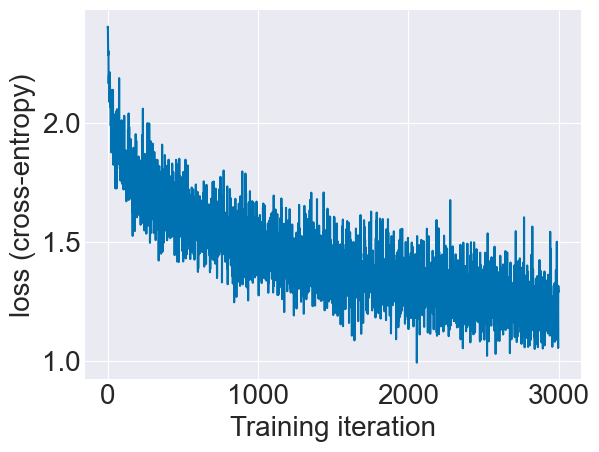

In [100]:
def plot_cross_entropy_loss(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Training iteration')
    plt.ylabel('loss (cross-entropy)')
    plt.show()
plot_cross_entropy_loss(loss_history)


### 2d. Questions

**Question 1.** What do you think the decrease in loss over the epochs tells us about the state of the training process? What's the future potential for improvement like?

**Answer 1:**

I think that this tells us that the network is getting close to having a great fit on the training data. We could improve a bit more until the curve has a noticeable plateau but we want to avoid overfitting.


**Question 2.** Below, write code to test regularization with training: check to make sure that the loss starts at ~155 for `reg=100`. Once you get this working, play around with the regularization parameter. You can drastically change the magnitude, but it should always remain nonnegative. 

(i) How does regularization affect the training loss and **why**?

(ii) Make a plot that shows the ~155 initial loss for `reg=100`.

**Answer 2:**

We use regularization to penalize larger weights and this adds a term to the loss function. This means that the training loss usually increases for higher regularization values. So initially with our regularization value of 100 we had a training loss of ~155 but with reg = 10000 the loss was ~15177.

Starting to train network...There will be 600 epochs and 7200 iterations total, 12 iter/epoch.
  Completed iter 0/7200. Training loss: 154.16.
  Completed iter 100/7200. Training loss: 22.55.
  Completed iter 200/7200. Training loss: 4.95.
  Completed iter 300/7200. Training loss: 2.58.
  Completed iter 400/7200. Training loss: 2.25.
  Completed iter 500/7200. Training loss: 2.23.
  Completed iter 600/7200. Training loss: 2.20.
  Completed iter 700/7200. Training loss: 2.21.
  Completed iter 800/7200. Training loss: 2.21.
  Completed iter 900/7200. Training loss: 2.22.
  Completed iter 1000/7200. Training loss: 2.22.
  Completed iter 1100/7200. Training loss: 2.22.
  Completed iter 1200/7200. Training loss: 2.20.
  Completed iter 1300/7200. Training loss: 2.21.
  Completed iter 1400/7200. Training loss: 2.20.
  Completed iter 1500/7200. Training loss: 2.20.
  Completed iter 1600/7200. Training loss: 2.22.
  Completed iter 1700/7200. Training loss: 2.21.
  Completed iter 1800/7200. Trai

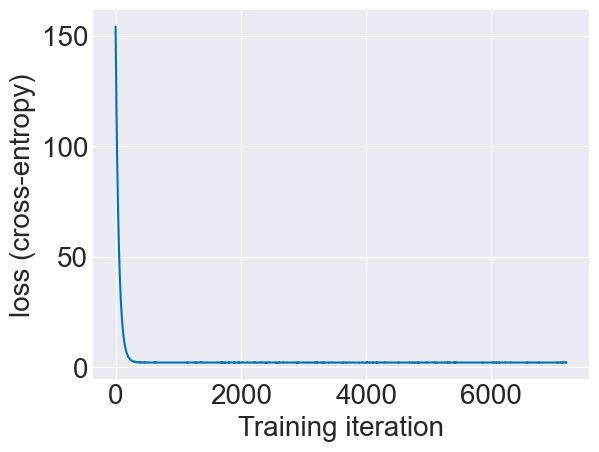

In [101]:
softmaxNet = SoftmaxLayer(10)
loss_history = softmaxNet.fit(X_train, y_train,
                              n_epochs=600,
                              mini_batch_sz=250,
                              r_seed=0,
                              reg = 100)

plot_cross_entropy_loss(loss_history)




**Question 3.** Play around with the batch size parameter.

(i) How does this affect the training loss and **why**? (*Think about the error gradient and how the weights change*)

(ii) Make a plot that showcases the effect of large mini-batch size.

(iii) Make a plot that showcases the effect of small mini-batch size.

**Answer 3:**

The training loss can be seen to be more stable and smooth with a large batch size because it takes less updates to the weights. The opposite is true for a small batch size. The gradients are caclulating rapidly but lack precision. Although training may take more iteratons with a small batch size the final loss is much lower.

Starting to train network...There will be 600 epochs and 3600 iterations total, 6 iter/epoch.
  Completed iter 0/3600. Training loss: 2.40.
  Completed iter 100/3600. Training loss: 2.22.
  Completed iter 200/3600. Training loss: 2.07.
  Completed iter 300/3600. Training loss: 2.06.
  Completed iter 400/3600. Training loss: 2.02.
  Completed iter 500/3600. Training loss: 1.95.
  Completed iter 600/3600. Training loss: 1.95.
  Completed iter 700/3600. Training loss: 1.94.
  Completed iter 800/3600. Training loss: 1.89.
  Completed iter 900/3600. Training loss: 1.93.
  Completed iter 1000/3600. Training loss: 1.89.
  Completed iter 1100/3600. Training loss: 1.83.
  Completed iter 1200/3600. Training loss: 1.90.
  Completed iter 1300/3600. Training loss: 1.90.
  Completed iter 1400/3600. Training loss: 1.86.
  Completed iter 1500/3600. Training loss: 1.83.
  Completed iter 1600/3600. Training loss: 1.78.
  Completed iter 1700/3600. Training loss: 1.85.
  Completed iter 1800/3600. Training

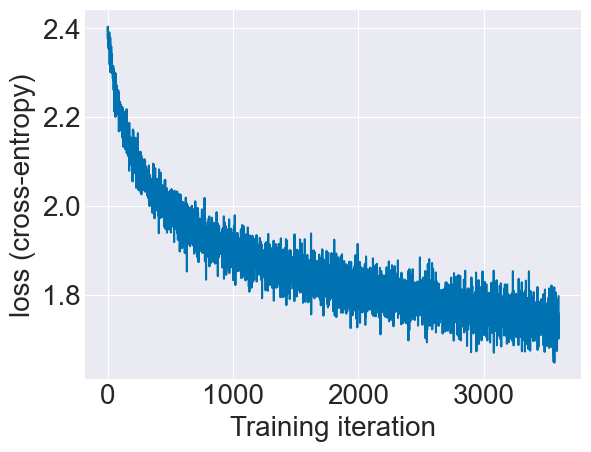

Starting to train network...There will be 600 epochs and 180000 iterations total, 300 iter/epoch.
  Completed iter 0/180000. Training loss: 2.45.
  Completed iter 100/180000. Training loss: 2.22.
  Completed iter 200/180000. Training loss: 2.16.
  Completed iter 300/180000. Training loss: 1.91.
  Completed iter 400/180000. Training loss: 1.93.
  Completed iter 500/180000. Training loss: 1.97.
  Completed iter 600/180000. Training loss: 1.90.
  Completed iter 700/180000. Training loss: 2.16.
  Completed iter 800/180000. Training loss: 1.58.
  Completed iter 900/180000. Training loss: 1.84.
  Completed iter 1000/180000. Training loss: 2.24.
  Completed iter 1100/180000. Training loss: 1.73.
  Completed iter 1200/180000. Training loss: 1.98.
  Completed iter 1300/180000. Training loss: 2.29.
  Completed iter 1400/180000. Training loss: 2.25.
  Completed iter 1500/180000. Training loss: 2.27.
  Completed iter 1600/180000. Training loss: 1.80.
  Completed iter 1700/180000. Training loss: 1.

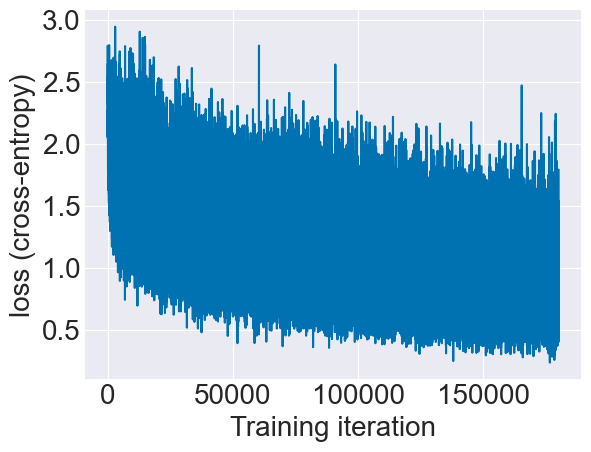

In [102]:
softmaxNet = SoftmaxLayer(10)
loss_history = softmaxNet.fit(X_train, y_train,
                              n_epochs=600,
                              mini_batch_sz=500,
                              r_seed=0)

plot_cross_entropy_loss(loss_history)

softmaxNet = SoftmaxLayer(10)
loss_history = softmaxNet.fit(X_train, y_train,
                              n_epochs=600,
                              mini_batch_sz=10,
                              r_seed=0)

plot_cross_entropy_loss(loss_history)

### 2e. Retraining the same net

Train 7 fresh softmax networks with default hyperparameters, except for `verbose=0`. Use the actual training set to train the networks rather than the dev set. Each time, compute and record the accuracy on the test set. After the 7 training sessions are over, print out all 7 accuracies.

In [103]:
softmaxNet_1 = SoftmaxLayer(10)
loss_history_1 = softmaxNet_1.fit(X_train, y_train, verbose=0)
print(softmaxNet_1.accuracy(y_train, softmaxNet_1.predict(X_train)))
softmaxNet_2 = SoftmaxLayer(10)
loss_history_2 = softmaxNet_2.fit(X_train, y_train, verbose=0)
print(softmaxNet_2.accuracy(y_train, softmaxNet_2.predict(X_train)))
softmaxNet_3 = SoftmaxLayer(10)
loss_history_3 = softmaxNet_3.fit(X_train, y_train, verbose=0)
print(softmaxNet_3.accuracy(y_train, softmaxNet_3.predict(X_train)))
softmaxNet_4 = SoftmaxLayer(10)
loss_history_4 = softmaxNet_4.fit(X_train, y_train, verbose=0)
print(softmaxNet_4.accuracy(y_train, softmaxNet_4.predict(X_train)))
softmaxNet_5 = SoftmaxLayer(10)
loss_history_5 = softmaxNet_5.fit(X_train, y_train, verbose=0)
print(softmaxNet_5.accuracy(y_train, softmaxNet_5.predict(X_train)))
softmaxNet_6 = SoftmaxLayer(10)
loss_history_6 = softmaxNet_6.fit(X_train, y_train, verbose=0)
print(softmaxNet_6.accuracy(y_train, softmaxNet_6.predict(X_train)))
softmaxNet_7 = SoftmaxLayer(10)
loss_history_7 = softmaxNet_7.fit(X_train, y_train, verbose=0)
print(softmaxNet_7.accuracy(y_train, softmaxNet_7.predict(X_train)))

0.318
0.32666666666666666
0.32866666666666666
0.3363333333333333
0.31533333333333335
0.3273333333333333
0.3233333333333333


### 2f. Questions

**Question: 4:** What do you notice about the accuracies? Is this what you expected? Why does this happen?

**Answer 4:**

I notice that the accuracies are all about the same with some small variation. I did expect this to happen because we are not fine-tuning our model from run to run so the only changes we should see come from our weight initialization and the mini-batch sampling (some randomness). 

### 2g. Train and optimize STL-10 dataset performance

As you've surely noticed, hyperparameters can drastically affect learning! 


Implement a grid search for the best **combinations** of hyperparameters

- learning rate,
- regularization
- batch size 

Fix the training duration to `75` epochs.

The grid search process should:

1. Fit the model with specific values of hyperparameters that we're testing (using the training set).
2. Compute the accuracy on the **training set**. 
3. Compute the accuracy on the **validation set.** 
4. Print out and record the best parameter combination as you go (that *improves* the **validation set accuracy**).
5. Wipe the weights clean (reinitialize them) every time you try new parameters. It's easiest just to create a new net object on each run.

Configure your search *in the way that we prefer from class* so that you get reproducible accuracy. For example, if your search prints out that the best hyperparameters give X% accuracy in the search, training a net with those same hyperparameters after the search is completed also gives you X% accuracy.

#### Suggestions

This can take quite a bit of simulation time! Here are some tips:
- I suggest using a coarse-to-fine search strategy. Try varying hyperparameters over many orders of magnitude, then follow up with a 2nd search that "zooms in" around the hyperparameters that gave you the best results from the first search, as determined by your print outs. You can be informal about this and hard-code the coarse and fine hyperparameter choices. Abort searches prematurely if you feel there aren't productive (no reason to wait!). This can take however long or short that you want to dedicate. Remember, you are printing out the best parameter values on each run, so you can always just proceed with those.
- High learning rates don't really make sense. You'll know if your value is "high" if numpy complains about numerical issues.
- Your mini-batch sizes should be `<= N` and `>= 1`.
- Time single network runs with a few different batch sizes you plan on trying in your big search. This will help you figure out a ballpark estimate how long grid search will take (*you can decide whether to go eat dinner, run it overnight, etc.*). If it will take an unreasonable amount of time, reduce the number of parameters you try in one search.
- Think about whether you need *3 nested loops* or *a sequence of single loops*.
- Turn off print outs from `fit` (adjust `verbose` argument) and only print out things related to your search.
- Feel free to try a search with more than 75 training epochs for potentially better accuracy, but note that the search will take longer to complete.

**Important note:** I am not grading based on the number of hours your computer spends searching. I want to see that you successfully implemented the grid search to find progressively better hyperparameters on STL-10 and use the outcome to inform your ultimate training session that you use to evaluate predictions on the test set. You should be able to achieve ~30% accuracy without too much effort. *Getting full credit here does not require you spending hours of searching!*

In [104]:
best_val_acc = 0
tuned_params = None
results = []

learning_rates = np.array([0.1, 0.01, 0.001])
regularizations = np.array([0.1, 0.01, 0.001])
batch_sizes = np.array([10, 100, 500])

for learning_rate in learning_rates:
    for reg in regularizations:
        for batch in batch_sizes:
            softmaxNet = SoftmaxLayer(10)
            loss_history = softmaxNet.fit(X_train, y_train,
                                          n_epochs=75,
                                          mini_batch_sz=batch,
                                          r_seed=0,
                                          lr=learning_rate,
                                          reg=reg,
                                          verbose=0
            )

            val_acc = softmaxNet.accuracy(y_val, softmaxNet.predict(x_val))
            results.append((learning_rate, reg, batch, val_acc))

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                tuned_params = (learning_rate, reg, batch)
                print(f"New best -> LR: {learning_rate}, Reg: {reg}, Batch Size: {batch}, Val Acc: {val_acc:.4f}")



print(f"Learning rate: {tuned_params[0]} \n Regularization: {tuned_params[1]} \n Batch size: {tuned_params[2]} \n Validation Accuracy: {best_val_acc:.4f}")
print("\n--- All Tried Configurations ---")
for lr, reg, bs, acc in results:
    print(f"LR: {lr}, Reg: {reg}, Batch Size: {b}, Val Acc: {acc:.4f}")


New best -> LR: 0.1, Reg: 0.1, Batch Size: 10, Val Acc: 0.2130
New best -> LR: 0.1, Reg: 0.1, Batch Size: 100, Val Acc: 0.2500
New best -> LR: 0.1, Reg: 0.1, Batch Size: 500, Val Acc: 0.2510
New best -> LR: 0.1, Reg: 0.01, Batch Size: 10, Val Acc: 0.2820
New best -> LR: 0.1, Reg: 0.01, Batch Size: 100, Val Acc: 0.3070
New best -> LR: 0.01, Reg: 0.1, Batch Size: 100, Val Acc: 0.3450
New best -> LR: 0.01, Reg: 0.1, Batch Size: 500, Val Acc: 0.3510
New best -> LR: 0.001, Reg: 0.01, Batch Size: 100, Val Acc: 0.3530
Learning rate: 0.001 
 Regularization: 0.01 
 Batch size: 100 
 Validation Accuracy: 0.3530

--- All Tried Configurations ---
LR: 0.1, Reg: 0.1, Batch Size: 1, Val Acc: 0.2130
LR: 0.1, Reg: 0.1, Batch Size: 1, Val Acc: 0.2500
LR: 0.1, Reg: 0.1, Batch Size: 1, Val Acc: 0.2510
LR: 0.1, Reg: 0.01, Batch Size: 1, Val Acc: 0.2820
LR: 0.1, Reg: 0.01, Batch Size: 1, Val Acc: 0.3070
LR: 0.1, Reg: 0.01, Batch Size: 1, Val Acc: 0.2980
LR: 0.1, Reg: 0.001, Batch Size: 1, Val Acc: 0.2710
LR

In [111]:
best_val_acc = 0
tuned_params = None
results = []

learning_rates = np.array([0.001, 0.0001, 0.0015, 0.0002])
regularizations = np.array([0.01, 0.05, 0.02, 0.1])
batch_sizes = np.array([100, 50, 75, 25])

for learning_rate in learning_rates:
    for reg in regularizations:
        for batch in batch_sizes:
            softmaxNet = SoftmaxLayer(10)
            loss_history = softmaxNet.fit(X_train, y_train,
                                          n_epochs=75,
                                          mini_batch_sz=batch,
                                          r_seed=0,
                                          lr=learning_rate,
                                          reg=reg,
                                          verbose=0
            )

            val_acc = softmaxNet.accuracy(y_val, softmaxNet.predict(x_val))
            results.append((learning_rate, reg, batch, val_acc))

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                tuned_params = (learning_rate, reg, batch)
                print(f"New best -> LR: {learning_rate}, Reg: {reg}, Batch Size: {batch}, Val Acc: {val_acc:.4f}")



print(f"Learning rate: {tuned_params[0]} \n Regularization: {tuned_params[1]} \n Batch size: {tuned_params[2]} \n Validation Accuracy: {best_val_acc:.4f}")
print("\n--- All Tried Configurations ---")
for lr, reg, bs, acc in results:
    print(f"LR: {lr}, Reg: {reg}, Batch Size: {b}, Val Acc: {acc:.4f}")

New best -> LR: 0.001, Reg: 0.01, Batch Size: 100, Val Acc: 0.3530
New best -> LR: 0.001, Reg: 0.05, Batch Size: 50, Val Acc: 0.3540
New best -> LR: 0.0015, Reg: 0.05, Batch Size: 75, Val Acc: 0.3550
Learning rate: 0.0015 
 Regularization: 0.05 
 Batch size: 75 
 Validation Accuracy: 0.3550

--- All Tried Configurations ---
LR: 0.001, Reg: 0.01, Batch Size: 1, Val Acc: 0.3530
LR: 0.001, Reg: 0.01, Batch Size: 1, Val Acc: 0.3470
LR: 0.001, Reg: 0.01, Batch Size: 1, Val Acc: 0.3470
LR: 0.001, Reg: 0.01, Batch Size: 1, Val Acc: 0.3430
LR: 0.001, Reg: 0.05, Batch Size: 1, Val Acc: 0.3530
LR: 0.001, Reg: 0.05, Batch Size: 1, Val Acc: 0.3540
LR: 0.001, Reg: 0.05, Batch Size: 1, Val Acc: 0.3500
LR: 0.001, Reg: 0.05, Batch Size: 1, Val Acc: 0.3450
LR: 0.001, Reg: 0.02, Batch Size: 1, Val Acc: 0.3530
LR: 0.001, Reg: 0.02, Batch Size: 1, Val Acc: 0.3470
LR: 0.001, Reg: 0.02, Batch Size: 1, Val Acc: 0.3510
LR: 0.001, Reg: 0.02, Batch Size: 1, Val Acc: 0.3450
LR: 0.001, Reg: 0.1, Batch Size: 1, Va

### 2h. Verify reproducibility of results  

Train a fresh net with the best hyperparameter values that you found in your search give you the best validation accuracy above.

Print out the accuracy on the validation set. It should match exactly your printout above.

In [ ]:
softmaxNet = SoftmaxLayer(10)
loss_history = softmaxNet.fit(X_train, y_train,
                              n_epochs=75,
                              mini_batch_sz=75,
                              r_seed=0,
                              lr=0.0015,
                              reg=0.05)
val_acc = softmaxNet.accuracy(y_val, softmaxNet.predict(x_val))
print(f"Val Acc: {val_acc:.4f}")

Starting to train network...There will be 75 epochs and 3000 iterations total, 40 iter/epoch.
  Completed iter 0/3000. Training loss: 2.47.
  Completed iter 100/3000. Training loss: 2.05.
  Completed iter 200/3000. Training loss: 1.94.
  Completed iter 300/3000. Training loss: 1.87.
  Completed iter 400/3000. Training loss: 1.77.
  Completed iter 500/3000. Training loss: 1.77.
  Completed iter 600/3000. Training loss: 1.49.
  Completed iter 700/3000. Training loss: 1.55.
  Completed iter 800/3000. Training loss: 1.57.
  Completed iter 900/3000. Training loss: 1.76.
  Completed iter 1000/3000. Training loss: 1.49.
  Completed iter 1100/3000. Training loss: 1.41.
  Completed iter 1200/3000. Training loss: 1.57.
  Completed iter 1300/3000. Training loss: 1.56.
  Completed iter 1400/3000. Training loss: 1.41.
  Completed iter 1500/3000. Training loss: 1.35.
  Completed iter 1600/3000. Training loss: 1.46.
  Completed iter 1700/3000. Training loss: 1.40.
  Completed iter 1800/3000. Training

### 2i. Evaluate best model on test set

**Question 5:** Now that you have "good" parameter values recorded, train a new model with the best learning rate, regularization strength, and batch size values in the cell below. What accuracy do you get on the **test set**? How does this compare to chance performance?

*Recall: The test set should NOT be used in your grid search. It should only be processed once AFTER you conclude your grid search.*

**Answer 5:**

Using our best (tuned) parameters we would hope at the very least that the training and validation accuracies set a floor for the test accuracy, i.e. we hope to see that our network will generalize well to the test set. As you can see from the printout below this is not true, our best parameters perform worse on the test set. Comparing to chance we can simply say that our model's ability to learn the data is worse than chance.

In [115]:
bestNet = SoftmaxLayer(10)
loss_history = bestNet.fit(X_train, y_train,
                              n_epochs=500,
                              mini_batch_sz=75,
                              r_seed=0,
                              lr=0.0015,
                              reg=0.05)

print(f"Accuracy: {bestNet.accuracy(y_test, bestNet.predict(x_test))}")

Starting to train network...There will be 500 epochs and 20000 iterations total, 40 iter/epoch.
  Completed iter 0/20000. Training loss: 2.47.
  Completed iter 100/20000. Training loss: 2.05.
  Completed iter 200/20000. Training loss: 1.94.
  Completed iter 300/20000. Training loss: 1.87.
  Completed iter 400/20000. Training loss: 1.77.
  Completed iter 500/20000. Training loss: 1.77.
  Completed iter 600/20000. Training loss: 1.49.
  Completed iter 700/20000. Training loss: 1.55.
  Completed iter 800/20000. Training loss: 1.57.
  Completed iter 900/20000. Training loss: 1.76.
  Completed iter 1000/20000. Training loss: 1.49.
  Completed iter 1100/20000. Training loss: 1.41.
  Completed iter 1200/20000. Training loss: 1.57.
  Completed iter 1300/20000. Training loss: 1.56.
  Completed iter 1400/20000. Training loss: 1.41.
  Completed iter 1500/20000. Training loss: 1.35.
  Completed iter 1600/20000. Training loss: 1.46.
  Completed iter 1700/20000. Training loss: 1.40.
  Completed iter

### 2j. Visualize learned weights

Run the following code that plots the network weights going to each output neuron. If all goes well, you should see something really cool! Include the plot in your submitted project to show me what you got!

**Note:** the quality of your visualizations will depend on:
- The quality of the hyperparameters that you got via grid search.
- How many epochs that you trained the network before plotting the weights

One extension idea: is to find the combination of the above that result in the best visualizations.

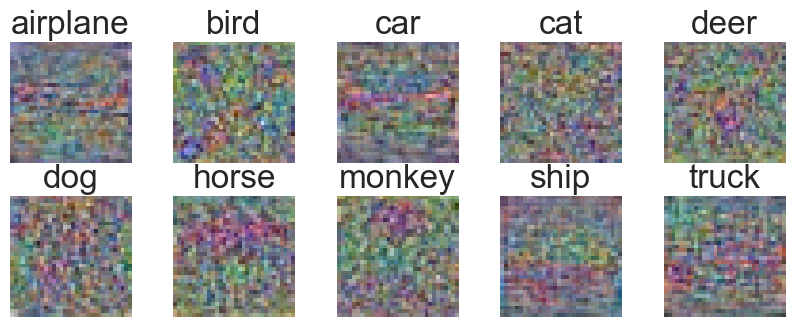

In [116]:
# Load in the class names
classes = np.loadtxt(os.path.join('data', 'stl10_binary', 'class_names.txt'), dtype=str)

# We don't care about the bias wt
wts = bestNet.wts
# Reshape the wt vectors into spatial 'image' configurations to visualization
wts = wts.reshape(32, 32, 3, 10)

# Make a large new empty figure/plot
plt.figure(figsize=(10, 4))

# Loop through each output neuron
for i in range(10):
  # Make a 2x5 grid of images
  plt.subplot(2, 5, i+1)

  # Rescale the weights to be between 0 and 255
  currImg = 255.0 * (wts[:, :, :, i].squeeze() - np.min(wts)) / (np.max(wts) - np.min(wts))

  plt.imshow(currImg.astype('uint8'))
  plt.axis('off')
  plt.title(classes[i])
plt.subplots_adjust(wspace=0.35, hspace=0)
plt.show()